# K-Means Clustering Analysis

K-means clustering with scikit-learn: the effect of the initialization method (random vs
k-means++), the number of clusters, the data distribution, and a discriminant-space projection on
the texture dataset. This notebook covers five experiments across initialization stability, cluster
count selection, and supervised projection for improved cluster quality.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import fetch_openml
import warnings; warnings.filterwarnings("ignore")
np.random.seed(0)

## Generate five well-separated 3-D groups

data shape: (500, 3)


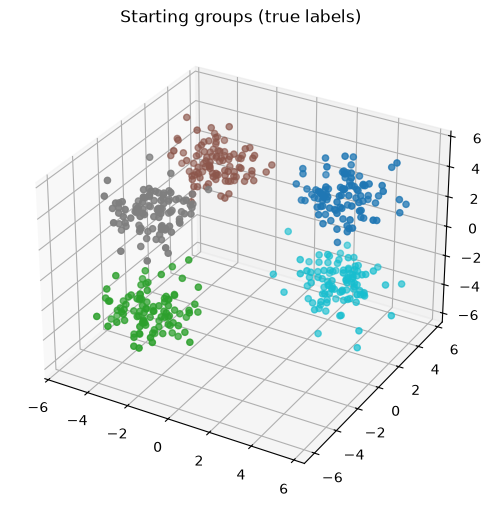

In [2]:
d1 = np.random.randn(100, 3) + [3, 3, 3]
d2 = np.random.randn(100, 3) + [-3, -3, -3]
d3 = np.random.randn(100, 3) + [-3, 3, 3]
d4 = np.random.randn(100, 3) + [-3, -3, 3]
d5 = np.random.randn(100, 3) + [3, 3, -3]
data = np.concatenate((d1, d2, d3, d4, d5))
labels = np.concatenate([(i + 1) * np.ones(100) for i in range(5)])
data, labels = shuffle(data, labels, random_state=0)
print("data shape:", data.shape)

fig = plt.figure(figsize=(7, 6)); ax = fig.add_subplot(111, projection="3d")
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=labels, cmap="tab10")
ax.set_title("Starting groups (true labels)"); plt.show()

In [3]:
# A single k-means++ run and a single random run
km_pp = KMeans(n_clusters=5, n_init=1, init="k-means++", random_state=0).fit(data)
km_rand = KMeans(n_clusters=5, n_init=1, init="random", random_state=0).fit(data)
print("ARI (k-means++):", round(metrics.adjusted_rand_score(km_pp.labels_, labels), 4))
print("ARI (random)   :", round(metrics.adjusted_rand_score(km_rand.labels_, labels), 4))

ARI (k-means++): 0.995
ARI (random)   : 0.995


## Question 1: Repeat each initialization several times

In [4]:
ari_pp, ari_rand = [], []
for seed in range(15):
    p = KMeans(n_clusters=5, n_init=1, init="k-means++", random_state=seed).fit(data)
    r = KMeans(n_clusters=5, n_init=1, init="random", random_state=seed).fit(data)
    ari_pp.append(metrics.adjusted_rand_score(p.labels_, labels))
    ari_rand.append(metrics.adjusted_rand_score(r.labels_, labels))
print(f"k-means++ : mean {np.mean(ari_pp):.3f} | min {np.min(ari_pp):.3f} | max {np.max(ari_pp):.3f}")
print(f"random    : mean {np.mean(ari_rand):.3f} | min {np.min(ari_rand):.3f} | max {np.max(ari_rand):.3f}")

k-means++ : mean 0.976 | min 0.715 | max 0.995
random    : mean 0.842 | min 0.700 | max 0.995


**Answer.** With k-means++ the adjusted Rand index is consistently close to 1 across runs,
because the smart initialization spreads the initial centroids out and almost always finds the five
true groups. Random initialization is less stable: on some runs two initial centroids land in the
same group and the algorithm converges to a worse local optimum, giving a lower Rand index. The
groups here are well separated, so random often succeeds too, but it fails more often than
k-means++, which is exactly why k-means++ (and using several restarts, `n_init > 1`) is preferred.

## Question 2: Vary the number of clusters

In [5]:
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(data)
    print(f"n_clusters={k}: ARI vs true labels = {metrics.adjusted_rand_score(km.labels_, labels):.4f}")

n_clusters=2: ARI vs true labels = 0.3689
n_clusters=3: ARI vs true labels = 0.6135
n_clusters=4: ARI vs true labels = 0.7764
n_clusters=5: ARI vs true labels = 0.9950
n_clusters=6: ARI vs true labels = 0.9294
n_clusters=7: ARI vs true labels = 0.8643


n_clusters=8: ARI vs true labels = 0.7725


**Answer.** The adjusted Rand index is highest at `n_clusters = 5`, the true number of groups.
With fewer clusters the algorithm is forced to merge real groups (ARI drops), and with more clusters
it splits real groups (ARI also drops). So the Rand index against the known labels peaks at the
correct k, which is consistent with how the data was generated.

## Question 3: Inertia (cost) vs the number of clusters

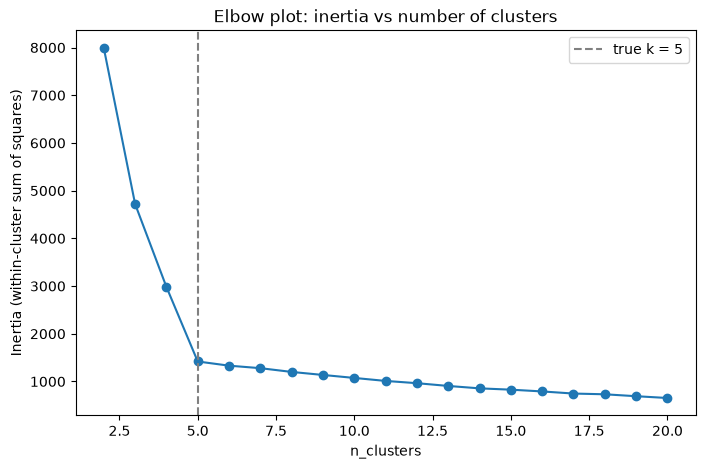

In [6]:
ks = range(2, 21)
inertia = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(data).inertia_ for k in ks]
plt.figure(figsize=(8, 5))
plt.plot(list(ks), inertia, marker="o")
plt.axvline(5, color="grey", ls="--", label="true k = 5")
plt.xlabel("n_clusters"); plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow plot: inertia vs number of clusters"); plt.legend(); plt.show()

**Answer.** Inertia falls monotonically as k increases (more clusters always fit the training
points better), but the curve has a clear **elbow at k = 5**: before 5 each added cluster removes a
lot of inertia, after 5 the gains flatten out. The elbow recovers the true number of groups without
using the labels, which is the standard way to choose k in practice.

## Question 4: Uniform data in the unit cube

In [7]:
uni = np.random.rand(500, 3)   # 500 points uniform in [0,1]^3
reference = KMeans(n_clusters=5, n_init=1, init="k-means++", random_state=0).fit(uni).labels_

uni_rand, uni_pp = [], []
for seed in range(1, 16):
    r = KMeans(n_clusters=5, n_init=1, init="random", random_state=seed).fit(uni)
    p = KMeans(n_clusters=5, n_init=1, init="k-means++", random_state=seed).fit(uni)
    uni_rand.append(metrics.adjusted_rand_score(r.labels_, reference))
    uni_pp.append(metrics.adjusted_rand_score(p.labels_, reference))
print(f"Uniform data - random init vs reference   : mean {np.mean(uni_rand):.3f} | min {np.min(uni_rand):.3f} | max {np.max(uni_rand):.3f}")
print(f"Uniform data - k-means++ init vs reference: mean {np.mean(uni_pp):.3f} | min {np.min(uni_pp):.3f} | max {np.max(uni_pp):.3f}")

Uniform data - random init vs reference   : mean 0.554 | min 0.319 | max 1.000
Uniform data - k-means++ init vs reference: mean 0.530 | min 0.345 | max 0.890


**Answer.** On the uniform data the Rand index between runs is far from 1 and varies a lot, even
with k-means++. The reason is that uniform data has **no real cluster structure**, so the boundaries
K-means draws are essentially arbitrary and shift from one initialization to the next. This is the
opposite of the Gaussian data, where genuine, well-separated groups exist and the partition is stable
and reproducible (ARI near 1). The contrast shows that K-means will always return k groups, but the
groups are only meaningful and stable when the data actually contains clusters.

## Section 4 + Question 5: Texture data, raw vs discriminant-space K-means

In [8]:
tex = fetch_openml("texture", version=1, as_frame=False)
X, ytrue = tex.data, tex.target.astype(int)
X, ytrue = shuffle(X, ytrue, random_state=0)
print("texture data:", X.shape, "| classes:", len(np.unique(ytrue)))

km_raw = KMeans(n_clusters=11, n_init=10, random_state=0).fit(X)
print("ARI - K-means on raw 40 features:", round(metrics.adjusted_rand_score(km_raw.labels_, ytrue), 4))

lda = LinearDiscriminantAnalysis(n_components=10)
X_lda = lda.fit_transform(X, ytrue)
km_lda = KMeans(n_clusters=11, n_init=10, random_state=0).fit(X_lda)
print("ARI - K-means on LDA-projected data:", round(metrics.adjusted_rand_score(km_lda.labels_, ytrue), 4))

texture data: (5500, 40) | classes: 11
ARI - K-means on raw 40 features: 0.4641
ARI - K-means on LDA-projected data: 0.9905


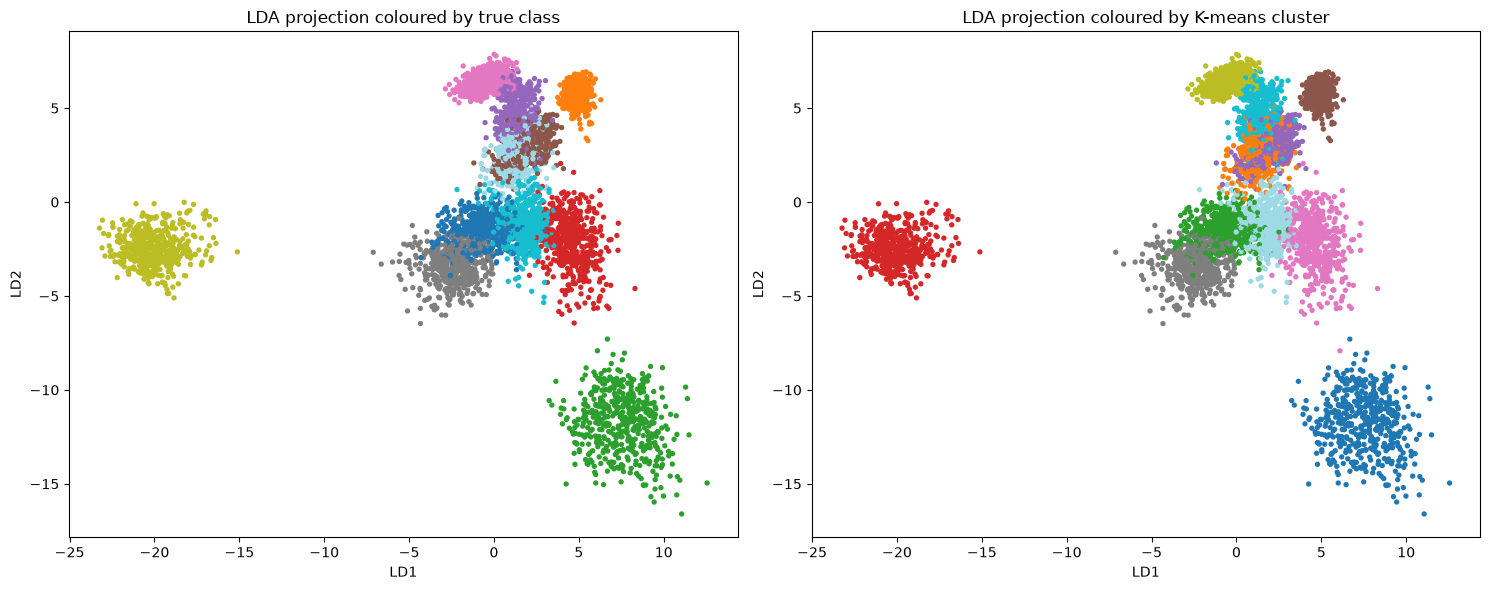

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(X_lda[:, 0], X_lda[:, 1], c=ytrue, cmap="tab20", s=8)
axes[0].set_title("LDA projection coloured by true class")
axes[1].scatter(X_lda[:, 0], X_lda[:, 1], c=km_lda.labels_, cmap="tab20", s=8)
axes[1].set_title("LDA projection coloured by K-means cluster")
for ax in axes: ax.set_xlabel("LD1"); ax.set_ylabel("LD2")
plt.tight_layout(); plt.show()

**Answer.** K-means on the raw 40 features only loosely matches the 11 texture classes (a modest
Rand index): the classes overlap in the original space, so distance-based clustering mixes them.
Applying linear discriminant analysis first projects the data into a 10-dimensional space chosen to
maximise between-class separation relative to within-class scatter. K-means on this projection lines
up much more closely with the true classes (a substantially higher Rand index), and the two scatter
plots (coloured by true class and by cluster) look almost identical. The lesson is that a
supervised, separation-enhancing projection can turn a hard clustering problem into an easy one.

## Summary

K-means is sensitive to initialization (k-means++ is more stable than random), and the right number
of clusters can be read off the elbow of the inertia curve and confirmed by the Rand index against
known labels. The method only produces meaningful, stable partitions when the data actually contains
clusters (Gaussian blobs vs uniform noise), and pre-processing that increases class separation, such
as LDA, can dramatically improve how well the clusters match the real classes.